# **Libraries**

In [1]:
# ========== Standard Libraries ==========
import os
import time

# ========== Third-party Libraries ==========
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========== IPython Utilities ==========
from IPython.display import clear_output
from IPython.core.magic import register_cell_magic

# ========== TensorFlow ==========
import tensorflow as tf
import tensorflow.image as tfi

# TensorFlow performance setting
AUTOTUNE = tf.data.AUTOTUNE

# ========== Keras Layers & Models ==========
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import (
    Layer,
    Conv2D,
    Conv2DTranspose,
    ReLU,
    Activation,
    Lambda,
    GroupNormalization,
    InputSpec,
)

# ========== IPython Custom Magic ==========
@register_cell_magic
def skip(line, cell):
    pass  # Skip execution of cell

2025-08-08 14:59:55.074282: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754665195.255389      18 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754665195.310556      18 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **Preprocessing Configurations**

In [2]:
CT_path = "/kaggle/input/ct-to-mri-cgan/Dataset/images/trainA"
MRI_path = "/kaggle/input/ct-to-mri-cgan/Dataset/images/trainB"
test_path = "/kaggle/input/ct-to-mri-cgan/Dataset/images/testA"

In [3]:
BUFFER_SIZE = 1000
AUG_PER_IMAGE = 4
BATCH_SIZE = 4
RANDOM_SEED = 42

# **Data loading and Preprocessing**

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, InputSpec
def count_images(directory):
    return sum(1 for file in os.scandir(directory) 
               if file.name.lower().endswith(('.jpg', '.jpeg', '.png')))

In [5]:
print(f'Total CT images: {count_images(CT_path)}')
print(f'Total MRI images: {count_images(MRI_path)}')


Total CT images: 1742
Total MRI images: 1744


In [6]:
def load_and_preprocess(file_path, augmentations_per_image=AUG_PER_IMAGE, seed=RANDOM_SEED):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.image.resize(image, [286, 286])  # Resize before cropping

    def augment_fn(i):
        aug_seed = tf.stack([seed, i])
        aug = tf.image.stateless_random_crop(image, [256, 256, 1], seed=aug_seed)
        aug = tf.image.stateless_random_flip_left_right(aug, seed=aug_seed + 1)
        aug = tf.cast(aug, tf.float32) / 127.5 - 1.0
        return aug

    if augmentations_per_image > 0:
        return tf.data.Dataset.range(augmentations_per_image).map(augment_fn)
    else:
        # Just return the resized + normalized image as a dataset
        image = tf.image.resize(image, [256, 256])
        image = tf.cast(image, tf.float32) / 127.5 - 1.0
        return tf.data.Dataset.from_tensors(image)

**Create datasets of CT and MRI**

In [7]:
#tf_monet = tf.data.Dataset.list_files(monet_path + "/*.jpg", shuffle=True)
#tf_photos = tf.data.Dataset.list_files(photos_path + "/*.jpg", shuffle=True)

tf_CT = tf.data.Dataset.list_files(CT_path + "/*.png", shuffle=False)
tf_MRI = tf.data.Dataset.list_files(MRI_path + "/*.jpg", shuffle=False)
tf_test = tf.data.Dataset.list_files(test_path + "/*.png", shuffle=False)

CT_dataset = (
    tf_CT
    .flat_map(lambda x: load_and_preprocess(x, seed=RANDOM_SEED))
    .shuffle(BUFFER_SIZE, seed=RANDOM_SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

MRI_dataset = (
    tf_MRI
    .flat_map(lambda x: load_and_preprocess(x, seed=RANDOM_SEED))
    .shuffle(BUFFER_SIZE, seed=RANDOM_SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf_test
    .flat_map(lambda x: load_and_preprocess(x, seed = RANDOM_SEED,augmentations_per_image = 0))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

I0000 00:00:1754665208.369450      18 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Counting data, can be excluded and deleted

# **Visualizing dataset in batches**

In [8]:
%%skip
def display_images_from_dataset(dataset, title='Images', num_batches=4) -> None:
    for batch in dataset.take(num_batches):
        batch = (batch + 1.0) / 2.0  # convert from [-1, 1] to [0, 1] for display
        batch = tf.clip_by_value(batch, 0.0, 1.0)  # just in case there are errors, but quite unnecessary
        batch_np = batch.numpy() # to numpy to display as the datasets are in form of tensors

        plt.figure(figsize=(15, 5))
        for i in range(batch_np.shape[0]):
            plt.subplot(1, batch_np.shape[0], i + 1)
            plt.imshow(batch_np[i],cmap='gray')
            plt.axis("off")
        plt.suptitle(title)
        plt.show()
display_images_from_dataset(CT_dataset, title="CT Augmented Batch")
display_images_from_dataset(MRI_dataset, title="MRI Augmented Batch")

# **Reflection Padding**

In [9]:
class ReflectionPadding2D(Layer):
    def __init__(self, padding=(1, 1), **kwargs):
        self.padding = tuple(padding)
        self.input_spec = [InputSpec(ndim=4)]
        super(ReflectionPadding2D, self).__init__(**kwargs)

    def call(self, x, mask=None):
        w_pad, h_pad = self.padding
        return tf.pad(x, [[0, 0], [h_pad, h_pad], [w_pad, w_pad], [0, 0]], mode='REFLECT')

    def compute_output_shape(self, input_shape):
        return (input_shape[0],
                input_shape[1] + 2 * self.padding[1],
                input_shape[2] + 2 * self.padding[0],
                input_shape[3])


# **Instance Normalization by Group Normalization**

In [10]:
class InstanceLikeGroupNorm(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.kwargs = kwargs
        self.gn = None

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gn = tf.keras.layers.GroupNormalization(groups=channels, axis=-1, **self.kwargs)

    def call(self, inputs):
        return self.gn(inputs)

# **Downsample and Upsample**

In [11]:
class DownsampleBlock(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, apply_norm=True):
        super().__init__()
        self.model = tf.keras.Sequential()
        self.model.add(layers.Conv2D(filters, kernel_size, strides=2, padding='same',
                                     kernel_initializer=tf.random_normal_initializer(0., 0.02),
                                     use_bias=False))
        if apply_norm:
            self.model.add(InstanceLikeGroupNorm())
        self.model.add(layers.LeakyReLU())

    def call(self, x):
        return self.model(x)


class UpsampleBlock(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size):
        super().__init__()
        self.model = tf.keras.Sequential([
            layers.Conv2DTranspose(filters, kernel_size, strides=2, padding='same',
                                   kernel_initializer=tf.random_normal_initializer(0., 0.02),
                                   use_bias=False),
            InstanceLikeGroupNorm(),
            layers.ReLU()
        ])

    def call(self, x):
        return self.model(x)

# **UNet Generator**

In [12]:
class UNetGenerator(tf.keras.Model):
    def __init__(self, output_channels=3, dropout_rate=0.5):
        super().__init__()
        self.initializer = tf.random_normal_initializer(0., 0.02)
        self.dropout_rate = dropout_rate

        # Initial Convolution
        self.pad1 = ReflectionPadding2D((3, 3))
        self.conv1 = layers.Conv2D(64, kernel_size=7, padding='valid',
                                   kernel_initializer=self.initializer, use_bias=False)
        self.norm1 = InstanceLikeGroupNorm()
        self.relu1 = layers.ReLU()
        self.drop1 = layers.Dropout(self.dropout_rate)

        # Encoder (Downsampling path)
        self.down1 = DownsampleBlock(128, 3)  # output: 128 channels
        self.down2 = DownsampleBlock(256, 3)  # output: 256 channels
        self.down3 = DownsampleBlock(512, 3)  # output: 512 channels

        # Bottleneck
        self.bottleneck = self.conv_block(512)

        # Decoder (Upsampling path)
        self.up3 = UpsampleBlock(256, 3)      # input: bottleneck → upsample → 256
        self.up2 = UpsampleBlock(128, 3)      # input: + down2 skip
        self.up1 = UpsampleBlock(64, 3)       # input: + down1 skip

        # Final
        self.pad_out = ReflectionPadding2D((3, 3))
        self.out_conv = layers.Conv2D(output_channels, kernel_size=7, padding='valid',
                                      kernel_initializer=self.initializer, activation='tanh')

    def conv_block(self, filters):
        return tf.keras.Sequential([
            layers.Conv2D(filters, kernel_size=3, strides=1, padding='same',
                          kernel_initializer=self.initializer, use_bias=False),
            InstanceLikeGroupNorm(),
            layers.ReLU(),
            layers.Dropout(self.dropout_rate)
        ])

    def call(self, inputs, training=None):
        # Initial Conv
        x = self.pad1(inputs)
        x = self.conv1(x)
        x = self.norm1(x, training=training)
        x = self.relu1(x)
        x = self.drop1(x, training=training)

        # Downsampling path (encoder)
        d1 = self.down1(x, training=training)  # 128
        d2 = self.down2(d1, training=training) # 256
        d3 = self.down3(d2, training=training) # 512

        # Bottleneck
        b = self.bottleneck(d3, training=training)

        # Upsampling path (decoder) with skip connections
        u3 = self.up3(b, training=training)
        u3 = tf.concat([u3, d2], axis=-1)

        u2 = self.up2(u3, training=training)
        u2 = tf.concat([u2, d1], axis=-1)

        u1 = self.up1(u2, training=training)
        # No concat for input because first conv doesn’t preserve spatial size

        # Final Conv
        out = self.pad_out(u1)
        return self.out_conv(out)


# **PatchGAN Discriminator**

In [13]:
class PatchGANDiscriminator(tf.keras.Model):
    def __init__(self, target=False):
        super().__init__()
        self.initializer = tf.random_normal_initializer(0., 0.02)
        self.target = target

        self.down1 = DownsampleBlock(64, 4, apply_norm=False)
        self.down2 = DownsampleBlock(128, 4)
        self.down3 = DownsampleBlock(256, 4)

        self.pad1 = ReflectionPadding2D((1, 1))
        self.conv = layers.Conv2D(512, 4, strides=1, padding='valid',
                                  kernel_initializer=self.initializer, use_bias=False)
        self.norm = InstanceLikeGroupNorm()
        self.leaky_relu = layers.LeakyReLU()

        self.pad2 = ReflectionPadding2D((1, 1))
        self.final = layers.Conv2D(1, 4, strides=1, padding='valid',
                                   kernel_initializer=self.initializer)

    def call(self, input_image, target_image=None, training=None):  # Added training
        x = tf.concat([input_image, target_image], axis=-1) if self.target else input_image
        x = self.down1(x, training=training)
        x = self.down2(x, training=training)
        x = self.down3(x, training=training)

        x = self.pad1(x)
        x = self.conv(x)
        x = self.norm(x, training=training)
        x = self.leaky_relu(x)

        x = self.pad2(x)
        return self.final(x)

# **Generators and Discriminators initializing and testing**

In [14]:
%%skip
# Generator: Translates images from CT → MRI
generator_ct_to_mri = UNetGenerator(output_channels=3)

# Generator: Translates images from MRI → CT
generator_mri_to_ct = UNetGenerator(output_channels=3)

# Discriminator: Judges real vs fake MRI images
discriminator_mri = PatchGANDiscriminator(target=False)

# Discriminator: Judges real vs fake CT images
discriminator_ct = PatchGANDiscriminator(target=False)


In [15]:
%%skip
def visualize_results(input_img, fake_img, reconstructed_img, title_prefix=""):
    input_img = (input_img + 1) / 2  # from [-1, 1] → [0, 1]
    fake_img = (fake_img + 1) / 2
    reconstructed_img = (reconstructed_img + 1) / 2

    plt.figure(figsize=(12, 4))

    titles = [f"{title_prefix}Input", f"{title_prefix}Fake", f"{title_prefix}Reconstructed"]
    images = [input_img[0], fake_img[0], reconstructed_img[0]]

    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [16]:
%%skip
sample_input = tf.random.normal([1, 256, 256, 3])

# Forward pass: CT → MRI → CT
fake_mri = generator_ct_to_mri(sample_input)
reconstructed_ct = generator_mri_to_ct(fake_mri)

# Discriminator outputs
decision_ct = discriminator_ct(sample_input)
decision_mri = discriminator_mri(fake_mri)

print("Fake MRI shape:          ", fake_mri.shape)
print("Reconstructed CT shape:  ", reconstructed_ct.shape)
print("Disc CT output shape:    ", decision_ct.shape)
print("Disc MRI output shape:   ", decision_mri.shape)

# Visualize results
visualize_results(sample_input, fake_mri, reconstructed_ct, title_prefix="CT → MRI → CT: ")

# **Loss Module**

In [17]:
class Loss:
    def __init__(self, real_image = None, synthetic_image = None, mode=None, LAMBDA=10, loss_object=None):
        self.real_img = real_image
        self.synth_img = synthetic_image
        self.mode = mode
        self.LAMBDA = LAMBDA
        self.loss_obj = loss_object

        if self.mode == 'Identity':
            self.value = self.identity_loss(self.real_img, self.synth_img)
        elif self.mode == 'Cycle':
            self.value = self.calc_cycle_loss(self.real_img, self.synth_img)
        elif self.mode == 'Generator':
            self.value = self.generator_loss(self.synth_img)
        elif self.mode == 'Discriminator':
            self.value = self.discriminator_loss(self.real_img, self.synth_img)
        else:
            raise ValueError(f"Unknown mode: {self.mode}")

    def discriminator_loss(self, real, generated):
        real_loss = self.loss_obj(tf.ones_like(real), real)
        generated_loss = self.loss_obj(tf.zeros_like(generated), generated)
        total_disc_loss = real_loss + generated_loss
        return total_disc_loss * 0.5

    def generator_loss(self, generated):
        return self.loss_obj(tf.ones_like(generated), generated)

    def calc_cycle_loss(self, real_image, cycled_image):
        loss1 = tf.reduce_mean(tf.abs(real_image - cycled_image))
        return self.LAMBDA * loss1

    def identity_loss(self, real_image, same_image):
        loss = tf.reduce_mean(tf.abs(real_image - same_image))
        return self.LAMBDA * 0.5 * loss


When calling Loss, put in the mode and use .value
Example:
identity_loss = Loss(real_image, same_image, mode="Identity", LAMBDA=10, loss_object=loss_obj).value


# **CycleGAN class**

In [18]:
class CycleGAN(tf.keras.Model):
    def __init__(self, generator_G, generator_F, discriminator_X, discriminator_Y):
        super().__init__()
        self.generator_G = generator_G  # X → Y (e.g. CT → MRI)
        self.generator_F = generator_F  # Y → X (e.g. MRI → CT)
        self.discriminator_X = discriminator_X  # Real vs Fake CT
        self.discriminator_Y = discriminator_Y  # Real vs Fake MRI

    def build(self, input_shape):
        dummy_input = tf.zeros(input_shape)
        _ = self.generator_G(dummy_input)
        _ = self.generator_F(dummy_input)
        _ = self.discriminator_X(dummy_input)
        _ = self.discriminator_Y(dummy_input)
        super().build(input_shape)

    def compile(self, generator_G_opt, generator_F_opt,
                discriminator_X_opt, discriminator_Y_opt,
                loss_obj, lambda_cycle=10):
        super().compile()
        self.generator_G_opt = generator_G_opt
        self.generator_F_opt = generator_F_opt
        self.discriminator_X_opt = discriminator_X_opt
        self.discriminator_Y_opt = discriminator_Y_opt
        self.loss_obj = loss_obj
        self.lambda_cycle = lambda_cycle

    def call(self, inputs):
        return self.generator_G(inputs)

    @tf.function
    def train_step(self, batch):
        real_X, real_Y = batch  # X: domain A (CT), Y: domain B (MRI)

        with tf.GradientTape(persistent=True) as tape:
            # === Forward Pass ===
            fake_Y = self.generator_G(real_X, training=True)  # G(X)
            fake_X = self.generator_F(real_Y, training=True)  # F(Y)

            cycled_X = self.generator_G(fake_Y, training=True)  # G(F(Y))
            cycled_Y = self.generator_F(fake_X, training=True)  # F(G(X))

            same_X = self.generator_F(real_X, training=True)   # Identity F(X)
            same_Y = self.generator_G(real_Y, training=True)   # Identity G(Y)

            # === Discriminator Outputs ===
            disc_real_X = self.discriminator_X(real_X, training=True)
            disc_fake_X = self.discriminator_X(fake_X, training=True)
            disc_real_Y = self.discriminator_Y(real_Y, training=True)
            disc_fake_Y = self.discriminator_Y(fake_Y, training=True)
            
            # === PSNR & SSIM ===
            psnr_X = tfi.psnr(real_X, cycled_X, max_val=2.0)  # Images in [-1, 1] → max_val=2
            psnr_Y = tfi.psnr(real_Y, cycled_Y, max_val=2.0)
            ssim_X = tfi.ssim(real_X, cycled_X, max_val=2.0)
            ssim_Y = tfi.ssim(real_Y, cycled_Y, max_val=2.0)
            
            mean_psnr = (tf.reduce_mean(psnr_X) + tf.reduce_mean(psnr_Y)) / 2
            mean_ssim = (tf.reduce_mean(ssim_X) + tf.reduce_mean(ssim_Y)) / 2

            # === Generator Losses ===
            gen_G_adv_loss = self.loss_obj(tf.ones_like(disc_fake_Y), disc_fake_Y)
            gen_F_adv_loss = self.loss_obj(tf.ones_like(disc_fake_X), disc_fake_X)

            cycle_loss_X = tf.reduce_mean(tf.abs(real_X - cycled_X))
            cycle_loss_Y = tf.reduce_mean(tf.abs(real_Y - cycled_Y))
            cycle_loss = self.lambda_cycle * (cycle_loss_X + cycle_loss_Y)

            id_loss_X = tf.reduce_mean(tf.abs(real_X - same_X))
            id_loss_Y = tf.reduce_mean(tf.abs(real_Y - same_Y))
            identity_loss = 0.5 * self.lambda_cycle * (id_loss_X + id_loss_Y)

            total_gen_G_loss = gen_G_adv_loss + cycle_loss + identity_loss
            total_gen_F_loss = gen_F_adv_loss + cycle_loss + identity_loss
            
            # === Discriminator Losses ===
            disc_X_loss = (
                self.loss_obj(tf.ones_like(disc_real_X), disc_real_X) +
                self.loss_obj(tf.zeros_like(disc_fake_X), disc_fake_X)
            ) * 0.5

            disc_Y_loss = (
                self.loss_obj(tf.ones_like(disc_real_Y), disc_real_Y) +
                self.loss_obj(tf.zeros_like(disc_fake_Y), disc_fake_Y)
            ) * 0.5

        # === Apply Gradients ===
        self.generator_G_opt.apply_gradients(
            zip(tape.gradient(total_gen_G_loss, self.generator_G.trainable_variables),
                self.generator_G.trainable_variables)
        )

        self.generator_F_opt.apply_gradients(
            zip(tape.gradient(total_gen_F_loss, self.generator_F.trainable_variables),
                self.generator_F.trainable_variables)
        )

        self.discriminator_X_opt.apply_gradients(
            zip(tape.gradient(disc_X_loss, self.discriminator_X.trainable_variables),
                self.discriminator_X.trainable_variables)
        )

        self.discriminator_Y_opt.apply_gradients(
            zip(tape.gradient(disc_Y_loss, self.discriminator_Y.trainable_variables),
                self.discriminator_Y.trainable_variables)
        )

        return {
            "gen_G_loss": total_gen_G_loss,
            "gen_F_loss": total_gen_F_loss,
            "disc_X_loss": disc_X_loss,
            "disc_Y_loss": disc_Y_loss,
            "cycle_loss": cycle_loss,
            "identity_loss": identity_loss,
            "psnr": mean_psnr,
            "ssim": mean_ssim
        }

    def generate_images(self, input_image):
        prediction = self.generator_G(input_image, training=False)
    
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        images = [input_image[0], prediction[0]]
        titles = ['Input Image', 'Generated Image (CT → MRI)']
    
        for ax, img, title in zip(axes, images, titles):
            img = (img + 1) / 2  # Rescale from [-1, 1] to [0, 1]
            if img.shape[-1] == 1:  # Grayscale image
                ax.imshow(img[..., 0], cmap='gray')
            else:
                ax.imshow(img)  # RGB image
            ax.set_title(title)
            ax.axis('off')
    
        plt.tight_layout()
        plt.show()

In [19]:
class CycleGANCallback(tf.keras.callbacks.Callback):
    def __init__(self, sample_image, checkpoint_path="./ckpts/epoch_{epoch}", save_freq=1):
        """
        Custom callback to:
        - Save full model every `save_freq` epochs.
        - Visualize sample image translation.

        Args:
            sample_image: A batch of input images (Tensor) for visualization.
            checkpoint_path: Directory path or base path format to save model.
            save_freq: Integer, save every N epochs.
        """
        super().__init__()
        self.sample_image = sample_image
        self.checkpoint_path = checkpoint_path
        self.save_freq = save_freq

    def on_epoch_end(self, epoch, logs=None):
        epoch_num = epoch + 1
        print(f"\nEpoch {epoch_num} completed.")

        # Generate sample images if possible
        if self.sample_image is not None:
            try:
                print("Generating sample images...")
                self.model.generate_images(self.sample_image)
            except Exception as e:
                print(f"[Warning] Could not generate images: {e}")

        # Save entire model at specified frequency
        if self.save_freq > 0 and epoch_num % self.save_freq == 0:
            save_path = self.checkpoint_path.format(epoch=epoch_num)
            try:
                self.model.save_weights(save_path)
                print(f"Model weights saved to: {save_path}")
            except Exception as e:
                print(f"[Error] Failed to save model: {e}")

# **Training**

In [20]:
# === 1. Define models ===
generator_G = UNetGenerator(output_channels=1,  dropout_rate=0.0)  # CT → MRI
generator_F = UNetGenerator(output_channels=1,  dropout_rate=0.0)  # MRI → CT
discriminator_Y = PatchGANDiscriminator(target=False)  # Real vs Fake MRI
discriminator_X = PatchGANDiscriminator(target=False)  # Real vs Fake CT

# === 2. Define optimizers ===
generator_G_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_F_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_X_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_Y_opt = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# === 3. Instantiate CycleGAN ===
cyclegan = CycleGAN(
    generator_G=generator_G,
    generator_F=generator_F,
    discriminator_X=discriminator_X,
    discriminator_Y=discriminator_Y,
)

# === 4. Compile CycleGAN ===
cyclegan.compile(
    generator_G_opt=generator_G_opt,
    generator_F_opt=generator_F_opt,
    discriminator_X_opt=discriminator_X_opt,
    discriminator_Y_opt=discriminator_Y_opt,
    loss_obj=tf.keras.losses.MeanSquaredError(),
    lambda_cycle=10
)

# === 5. Build the model (dummy input ensures optimizers are active for restore/save) ===
cyclegan.build(input_shape=(BATCH_SIZE, 256, 256, 1))

# === 6. Prepare dataset ===
train_dataset = tf.data.Dataset.zip((CT_dataset, MRI_dataset))

# === 7. Prepare callbacks ===
sample_image = next(iter(CT_dataset.take(1)))  # For monitoring
checkpoint_path = "/kaggle/working/cyclegan.weights.h5"

callbacks = [
    CycleGANCallback(
        sample_image=sample_image,
        checkpoint_path=checkpoint_path,
        save_freq=1
    )
]

# === 8. Init ===
cyclegan.fit(
    train_dataset,
    epochs=0,
    callbacks=callbacks,
)

I0000 00:00:1754665213.683342      18 cuda_dnn.cc:529] Loaded cuDNN version 90300


**Cho đường dẫn model train rồi vô đây**

In [21]:
%%skip
cyclegan.load_weights("/kaggle/input/20-epochs/cyclegan.weights.h5") # Chỗ này 
print("Weights loaded successfully")

Epoch 1/10


I0000 00:00:1754665278.057414      55 service.cc:148] XLA service 0x7e758c00f300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754665278.058317      55 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
W0000 00:00:1754665281.207711      55 assert_op.cc:38] Ignoring Assert operator StatefulPartitionedCall/PSNR/Assert/Assert
W0000 00:00:1754665281.208739      55 assert_op.cc:38] Ignoring Assert operator StatefulPartitionedCall/PSNR/Assert_1/Assert
W0000 00:00:1754665281.208826      55 assert_op.cc:38] Ignoring Assert operator StatefulPartitionedCall/PSNR_1/Assert/Assert
W0000 00:00:1754665281.208958      55 assert_op.cc:38] Ignoring Assert operator StatefulPartitionedCall/PSNR_1/Assert_1/Assert
W0000 00:00:1754665281.210345      55 assert_op.cc:38] Ignoring Assert operator StatefulPartitionedCall/SSIM/Assert/Assert
W0000 00:00:1754665281.211062      55 assert_op.cc:38] Ignoring Assert operator 

   1742/Unknown 870s 451ms/step - cycle_loss: 1.7510 - disc_X_loss: 0.2163 - disc_Y_loss: 0.2152 - gen_F_loss: 3.2831 - gen_G_loss: 3.2920 - identity_loss: 0.9216 - psnr: 23.9411 - ssim: 0.7389
Epoch 1 completed.
Generating sample images...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


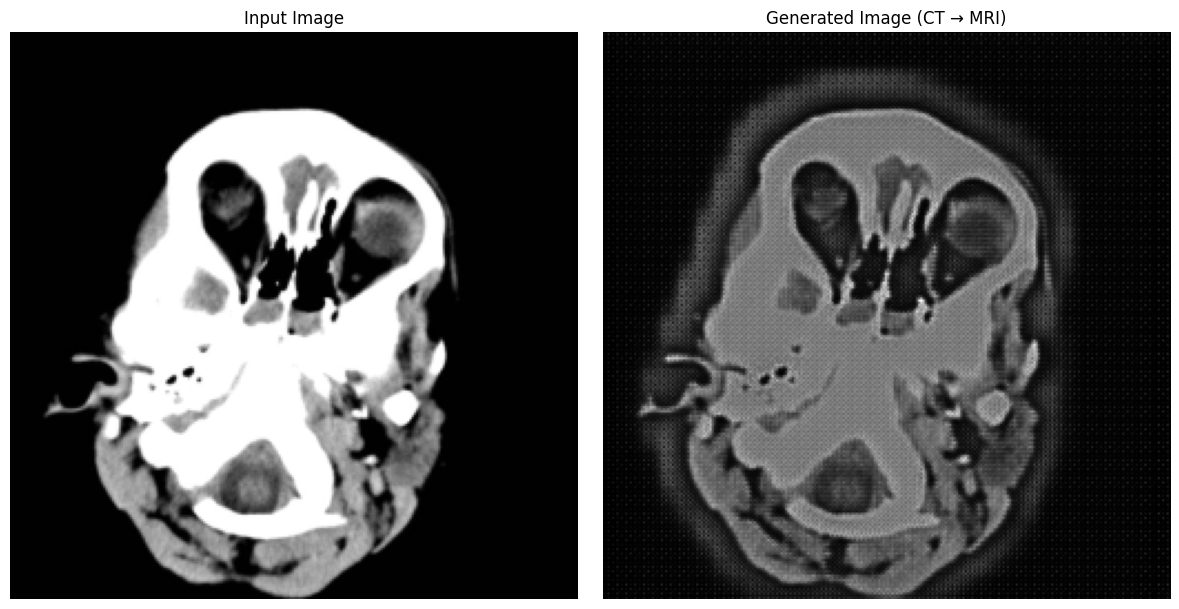

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 871s 452ms/step - cycle_loss: 1.7506 - disc_X_loss: 0.2163 - disc_Y_loss: 0.2151 - gen_F_loss: 3.2825 - gen_G_loss: 3.2914 - identity_loss: 0.9215 - psnr: 23.9432 - ssim: 0.7389
Epoch 2/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - cycle_loss: 1.3795 - disc_X_loss: 0.1780 - disc_Y_loss: 0.1504 - gen_F_loss: 2.6314 - gen_G_loss: 2.6925 - identity_loss: 0.6572 - psnr: 25.9248 - ssim: 0.8029
Epoch 2 completed.
Generating sample images...


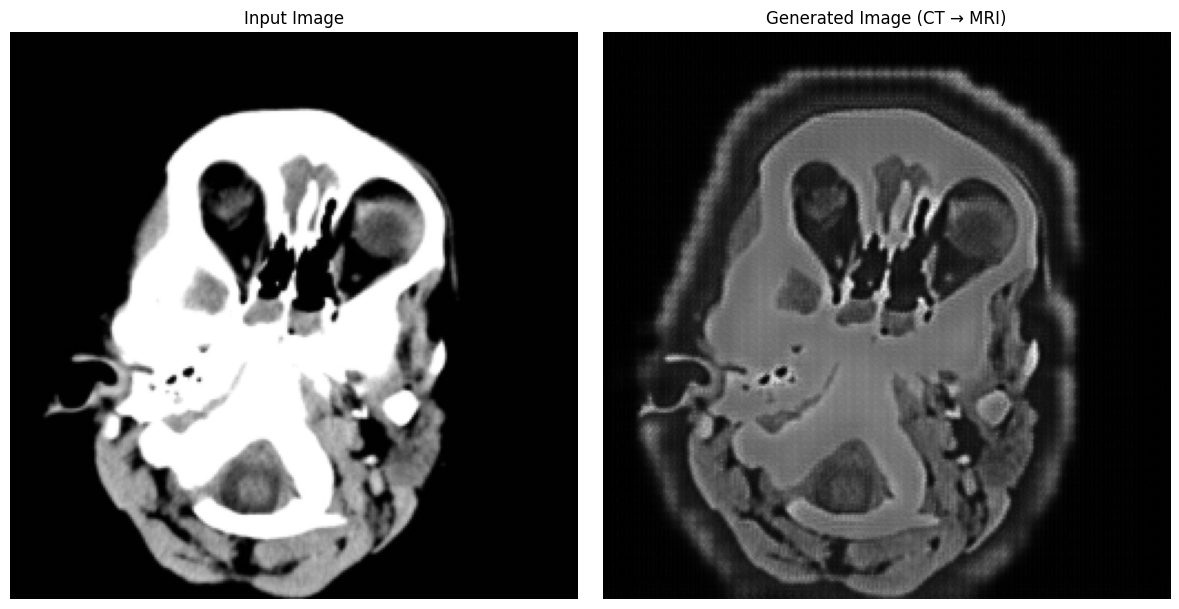

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 790s 452ms/step - cycle_loss: 1.3792 - disc_X_loss: 0.1779 - disc_Y_loss: 0.1504 - gen_F_loss: 2.6309 - gen_G_loss: 2.6920 - identity_loss: 0.6570 - psnr: 25.9264 - ssim: 0.8030
Epoch 3/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - cycle_loss: 1.2920 - disc_X_loss: 0.1842 - disc_Y_loss: 0.1508 - gen_F_loss: 2.4389 - gen_G_loss: 2.5341 - identity_loss: 0.5930 - psnr: 26.3106 - ssim: 0.8160
Epoch 3 completed.
Generating sample images...


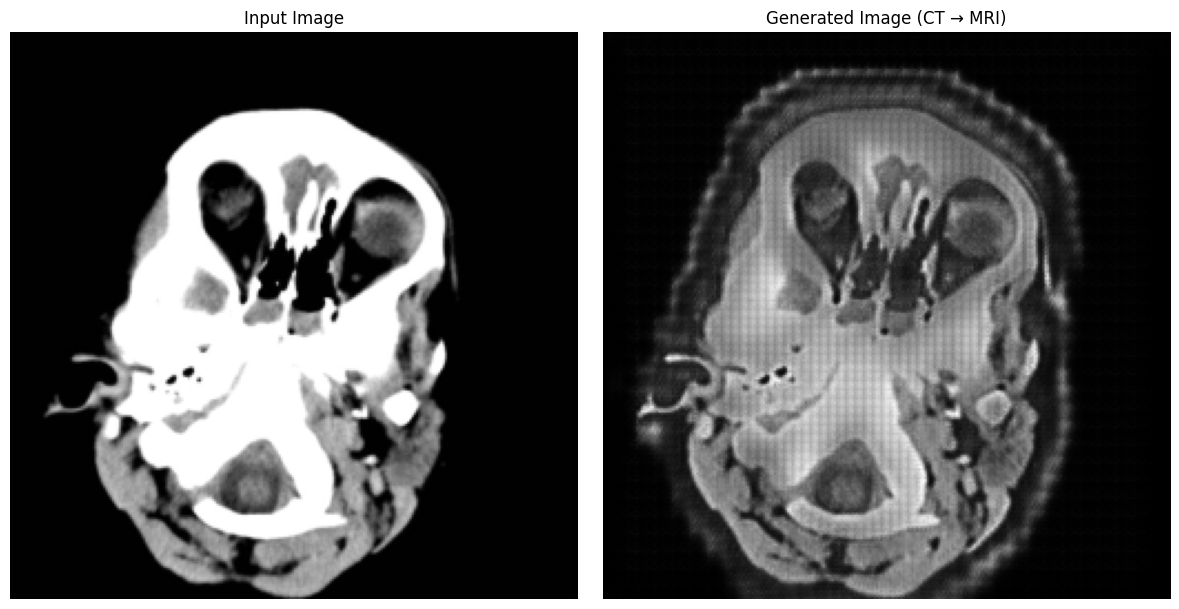

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 790s 452ms/step - cycle_loss: 1.2919 - disc_X_loss: 0.1842 - disc_Y_loss: 0.1507 - gen_F_loss: 2.4388 - gen_G_loss: 2.5340 - identity_loss: 0.5929 - psnr: 26.3113 - ssim: 0.8160
Epoch 4/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - cycle_loss: 1.2518 - disc_X_loss: 0.2048 - disc_Y_loss: 0.1825 - gen_F_loss: 2.3422 - gen_G_loss: 2.3833 - identity_loss: 0.5194 - psnr: 26.2927 - ssim: 0.8180
Epoch 4 completed.
Generating sample images...


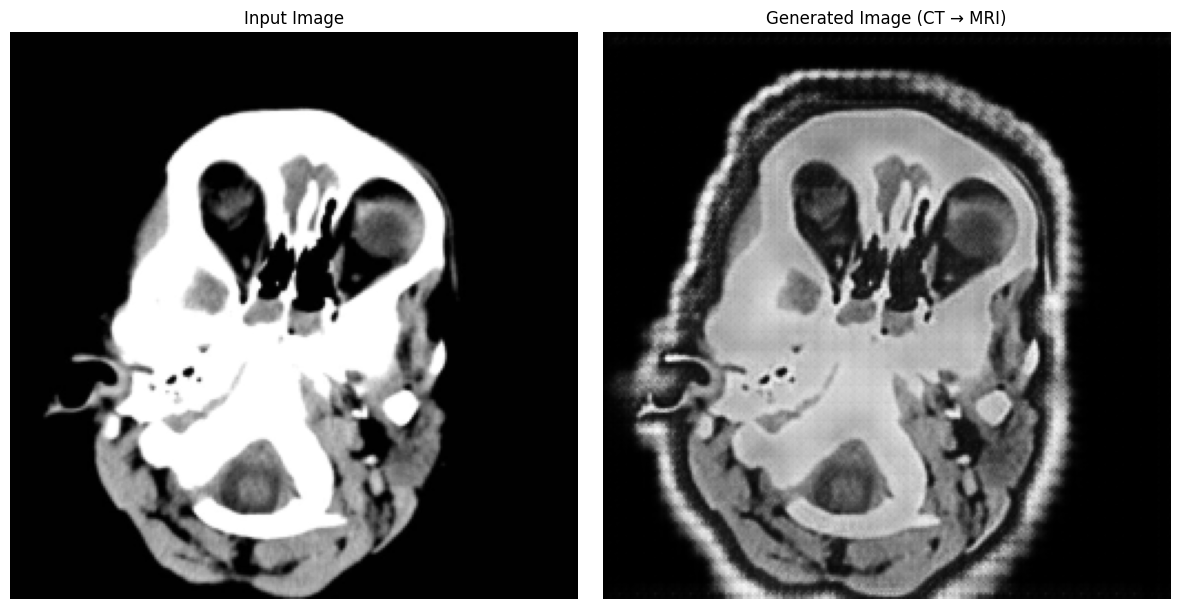

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 790s 452ms/step - cycle_loss: 1.2515 - disc_X_loss: 0.2048 - disc_Y_loss: 0.1826 - gen_F_loss: 2.3415 - gen_G_loss: 2.3826 - identity_loss: 0.5193 - psnr: 26.2952 - ssim: 0.8181
Epoch 5/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - cycle_loss: 1.0809 - disc_X_loss: 0.1938 - disc_Y_loss: 0.1696 - gen_F_loss: 1.9959 - gen_G_loss: 2.0600 - identity_loss: 0.4515 - psnr: 27.6328 - ssim: 0.8460
Epoch 5 completed.
Generating sample images...


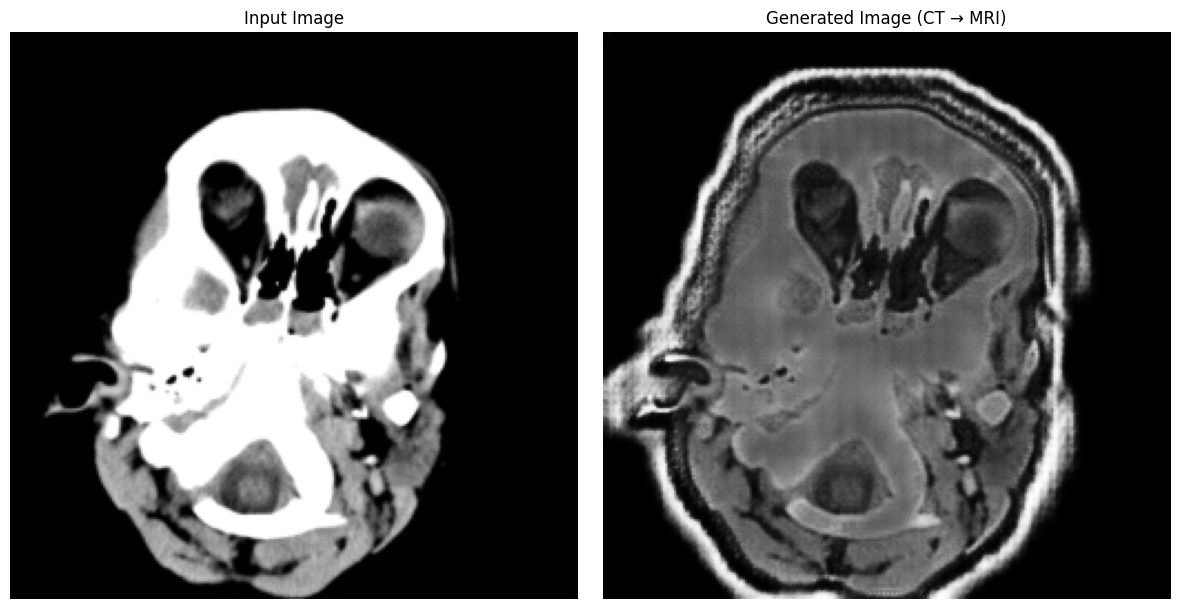

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 790s 452ms/step - cycle_loss: 1.0809 - disc_X_loss: 0.1939 - disc_Y_loss: 0.1696 - gen_F_loss: 1.9958 - gen_G_loss: 2.0598 - identity_loss: 0.4514 - psnr: 27.6320 - ssim: 0.8460
Epoch 6/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - cycle_loss: 1.1728 - disc_X_loss: 0.1652 - disc_Y_loss: 0.2084 - gen_F_loss: 2.1970 - gen_G_loss: 2.2003 - identity_loss: 0.4473 - psnr: 26.8156 - ssim: 0.8268
Epoch 6 completed.
Generating sample images...


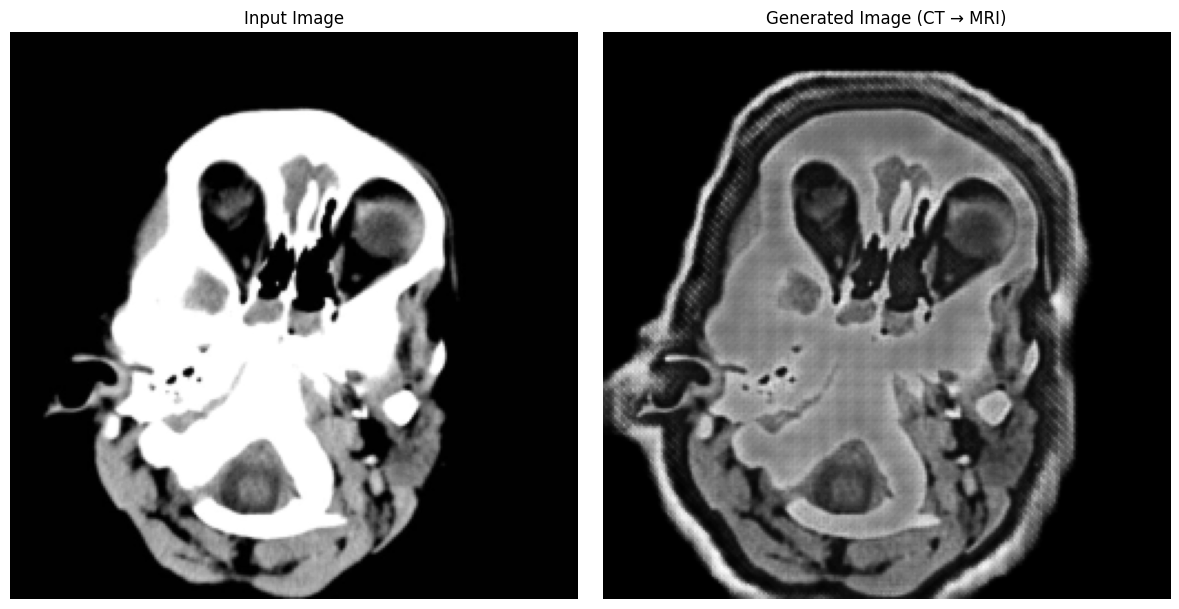

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 790s 452ms/step - cycle_loss: 1.1727 - disc_X_loss: 0.1652 - disc_Y_loss: 0.2084 - gen_F_loss: 2.1967 - gen_G_loss: 2.2000 - identity_loss: 0.4473 - psnr: 26.8171 - ssim: 0.8268
Epoch 7/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - cycle_loss: 0.9252 - disc_X_loss: 0.2195 - disc_Y_loss: 0.2528 - gen_F_loss: 1.7706 - gen_G_loss: 1.5763 - identity_loss: 0.3617 - psnr: 30.4405 - ssim: 0.8772
Epoch 7 completed.
Generating sample images...


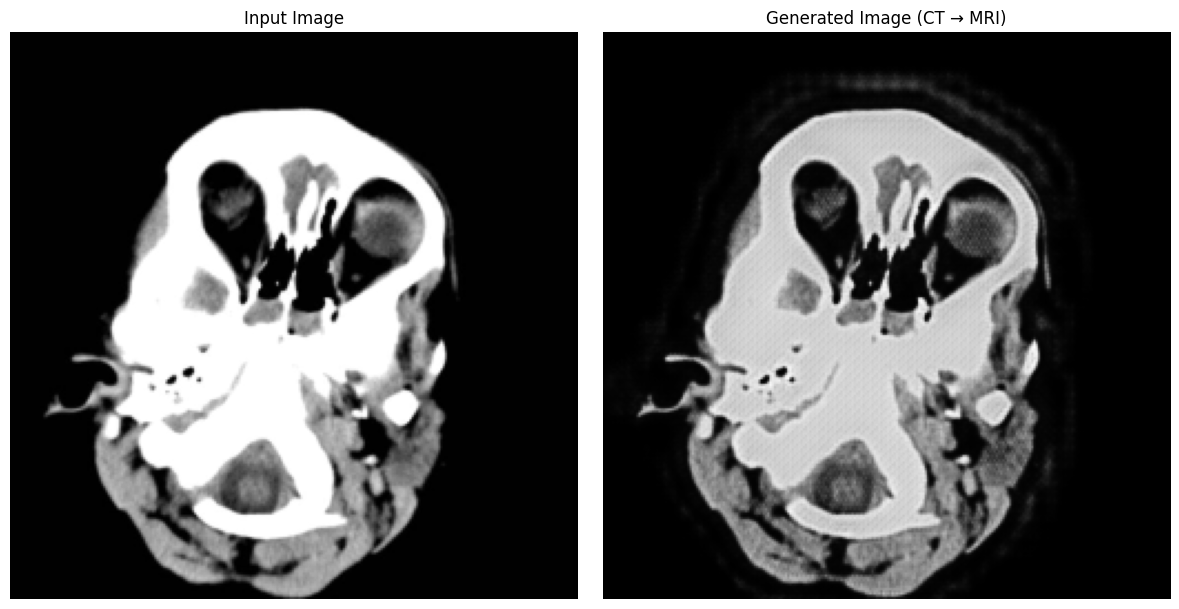

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 790s 452ms/step - cycle_loss: 0.9250 - disc_X_loss: 0.2195 - disc_Y_loss: 0.2528 - gen_F_loss: 1.7703 - gen_G_loss: 1.5760 - identity_loss: 0.3617 - psnr: 30.4415 - ssim: 0.8772
Epoch 8/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - cycle_loss: 0.9586 - disc_X_loss: 0.1582 - disc_Y_loss: 0.2510 - gen_F_loss: 1.8645 - gen_G_loss: 1.6188 - identity_loss: 0.3392 - psnr: 30.2012 - ssim: 0.8683
Epoch 8 completed.
Generating sample images...


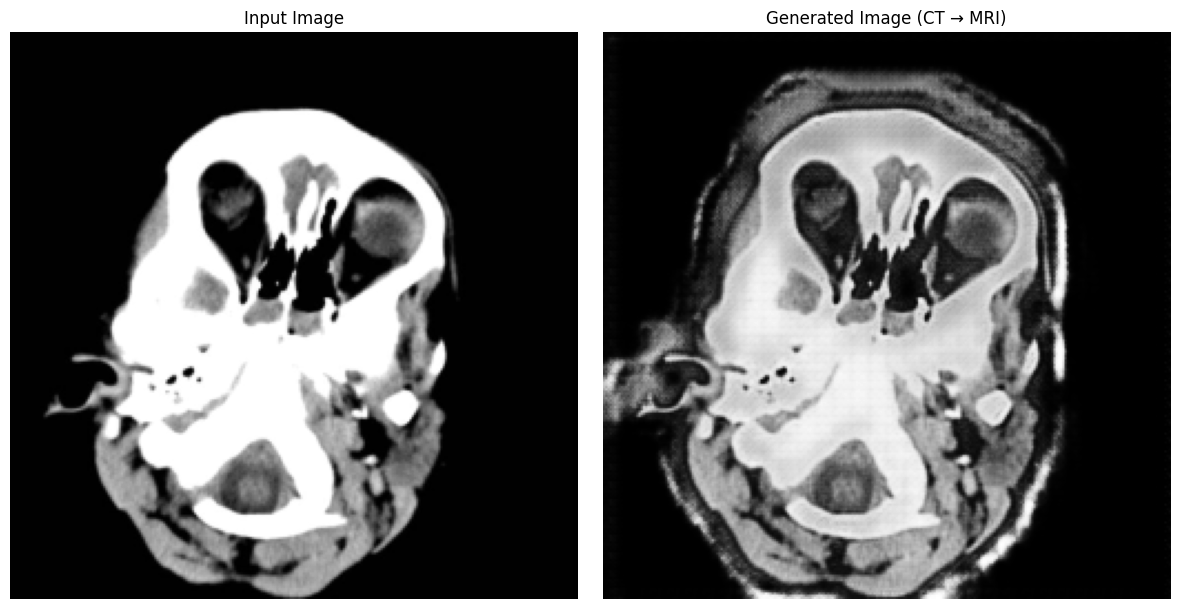

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 789s 451ms/step - cycle_loss: 0.9586 - disc_X_loss: 0.1582 - disc_Y_loss: 0.2509 - gen_F_loss: 1.8645 - gen_G_loss: 1.6188 - identity_loss: 0.3392 - psnr: 30.2011 - ssim: 0.8683
Epoch 9/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - cycle_loss: 0.9378 - disc_X_loss: 0.1756 - disc_Y_loss: 0.2337 - gen_F_loss: 1.8242 - gen_G_loss: 1.6393 - identity_loss: 0.3323 - psnr: 29.8947 - ssim: 0.8699
Epoch 9 completed.
Generating sample images...


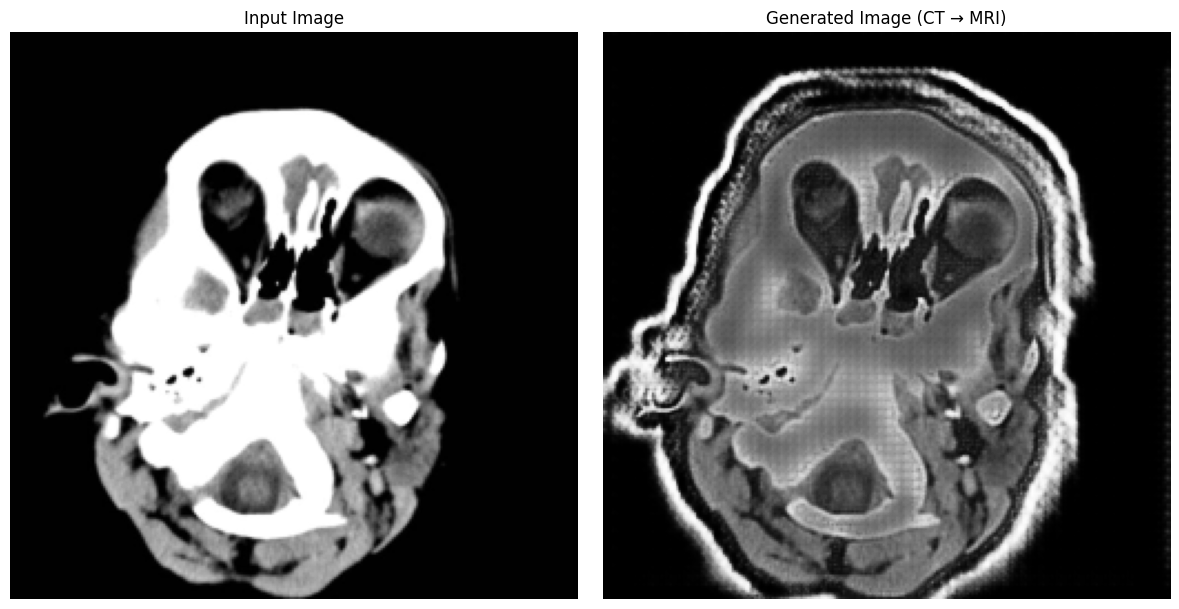

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 788s 451ms/step - cycle_loss: 0.9378 - disc_X_loss: 0.1756 - disc_Y_loss: 0.2337 - gen_F_loss: 1.8242 - gen_G_loss: 1.6393 - identity_loss: 0.3323 - psnr: 29.8944 - ssim: 0.8699
Epoch 10/10
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - cycle_loss: 0.9519 - disc_X_loss: 0.1683 - disc_Y_loss: 0.2116 - gen_F_loss: 1.8629 - gen_G_loss: 1.6974 - identity_loss: 0.3228 - psnr: 29.2573 - ssim: 0.8672
Epoch 10 completed.
Generating sample images...


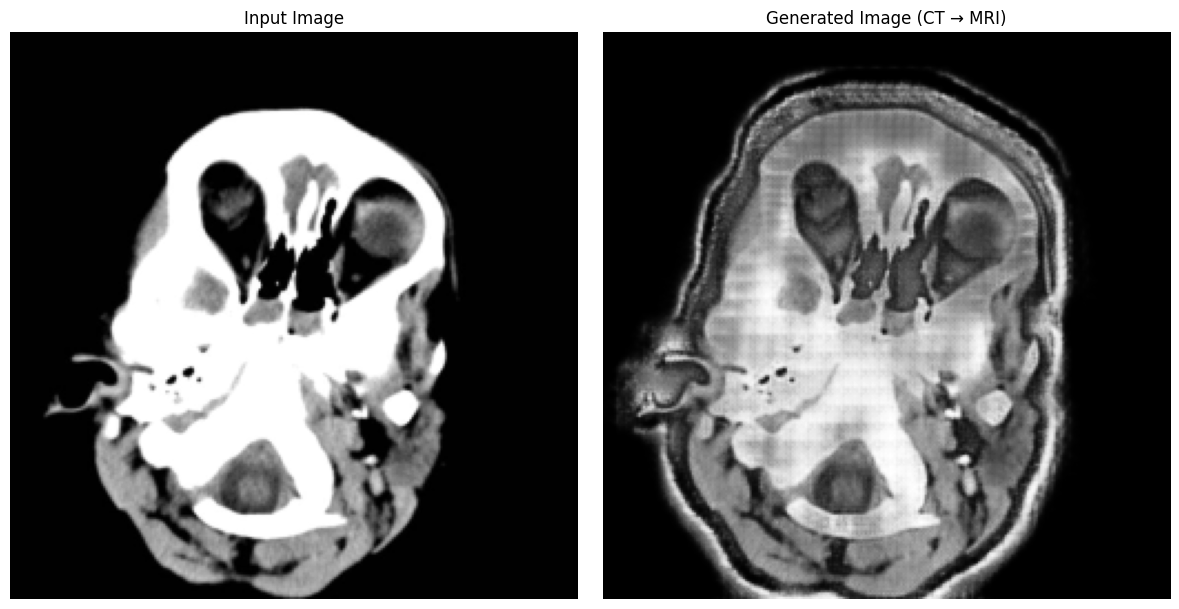

Model weights saved to: /kaggle/working/cyclegan.weights.h5
1742/1742 ━━━━━━━━━━━━━━━━━━━━ 789s 451ms/step - cycle_loss: 0.9518 - disc_X_loss: 0.1684 - disc_Y_loss: 0.2116 - gen_F_loss: 1.8627 - gen_G_loss: 1.6974 - identity_loss: 0.3229 - psnr: 29.2578 - ssim: 0.8672


In [22]:
history = cyclegan.fit(
    train_dataset,
    epochs=10,
    callbacks=callbacks,
)

In [23]:
history.history.keys()

dict_keys(['cycle_loss', 'disc_X_loss', 'disc_Y_loss', 'gen_F_loss', 'gen_G_loss', 'identity_loss', 'psnr', 'ssim'])

In [24]:
def plot_psnr_ssim(history):
    epochs = range(1, len(history['psnr']) + 1)

    plt.figure(figsize=(12, 5))

    # PSNR subplot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['psnr'], color='blue', label='PSNR')
    plt.xlabel('Epoch')
    plt.ylabel('PSNR Value')
    plt.title('PSNR Over Epochs')
    plt.grid(True)
    plt.legend()

    # SSIM subplot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['ssim'], color='green', label='SSIM')
    plt.xlabel('Epoch')
    plt.ylabel('SSIM Value')
    plt.title('SSIM Over Epochs')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [25]:
def plot_generator_losses(history):
    epochs = range(1, len(history['gen_G_loss']) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history['gen_G_loss'], label='gen_G_loss (CT→MRI)')
    plt.plot(epochs, history['gen_F_loss'], label='gen_F_loss (MRI→CT)')
    plt.plot(epochs, history['cycle_loss'], label='cycle_loss')
    plt.plot(epochs, history['identity_loss'], label='identity_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Generator-related Losses')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [26]:
def plot_discriminator_losses(history):
    epochs = range(1, len(history['disc_X_loss']) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, history['disc_X_loss'], label='disc_X_loss (CT)')
    plt.plot(epochs, history['disc_Y_loss'], label='disc_Y_loss (MRI)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Discriminator Losses')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [27]:
import pickle

# Save it to file
with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [28]:
with open('/kaggle/working/history.pkl', 'rb') as f:
    history_dict = pickle.load(f)

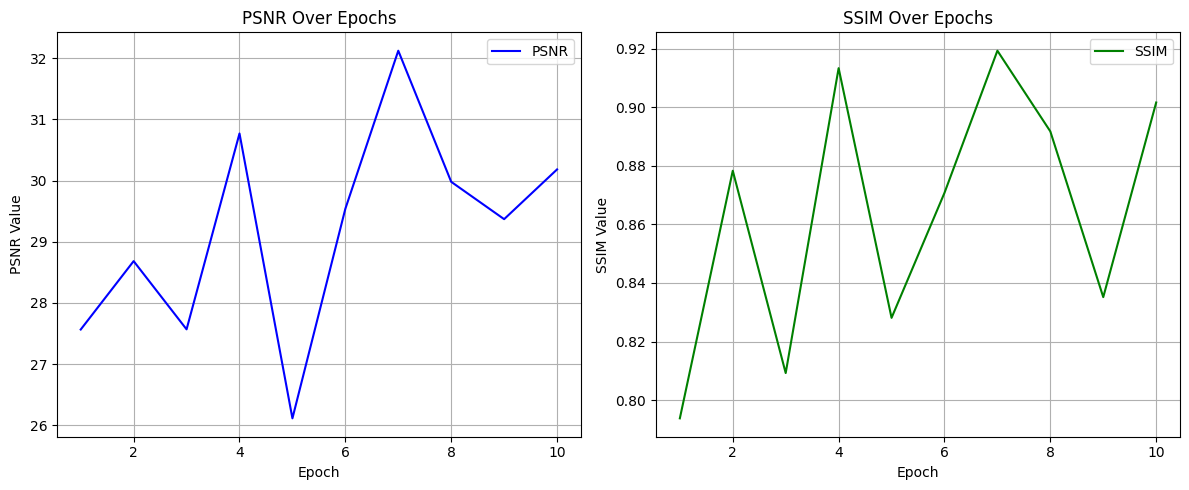

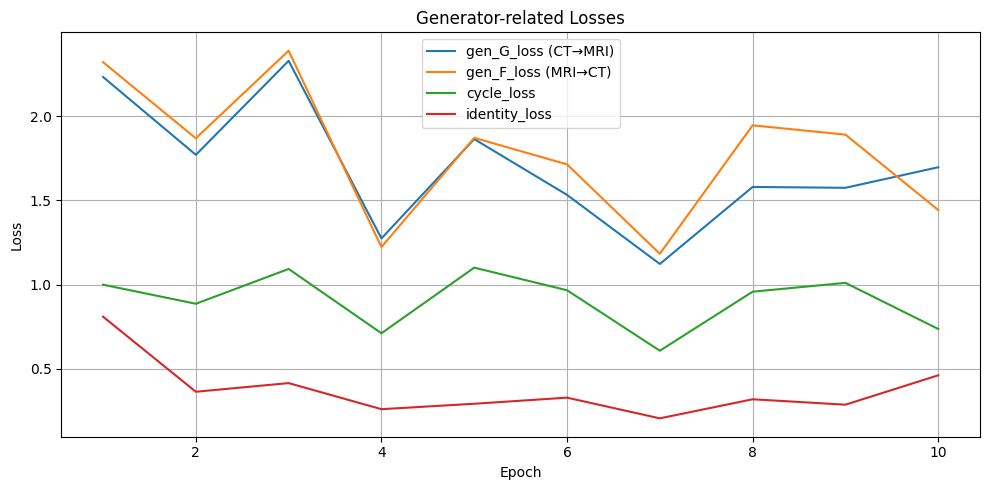

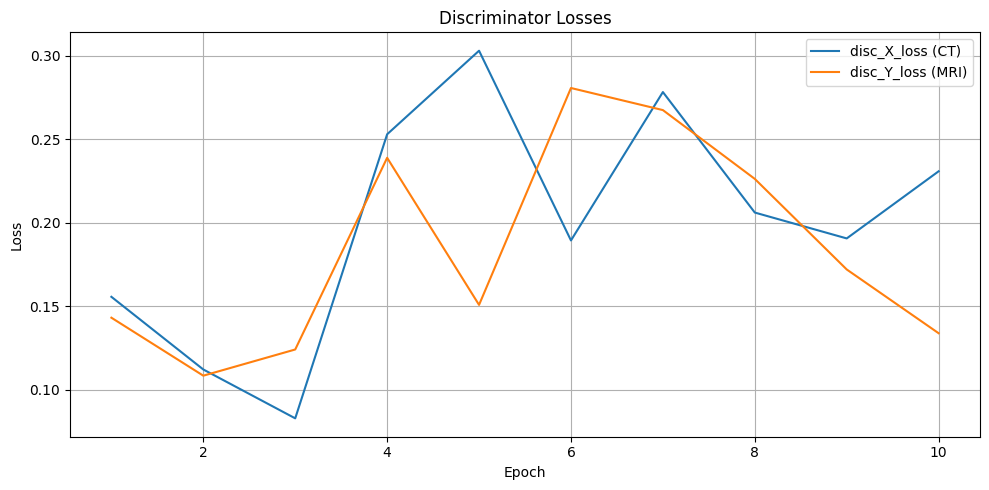

In [29]:
plot_psnr_ssim(history_dict)
plot_generator_losses(history_dict)
plot_discriminator_losses(history_dict)

In [30]:
def show_image_batch(input_batch, generated_batch):
    input_batch = (input_batch + 1) / 2  # Convert from [-1, 1] to [0, 1]
    generated_batch = (generated_batch + 1) / 2

    batch_size = input_batch.shape[0]
    plt.figure(figsize=(8, batch_size * 2))

    for i in range(batch_size):
        # Input photo
        plt.subplot(batch_size, 2, 2 * i + 1)
        plt.imshow(input_batch[i].numpy(),cmap='gray')
        plt.title("Input Photo")
        plt.axis('off')

        # Generated MRI
        plt.subplot(batch_size, 2, 2 * i + 2)
        plt.imshow(generated_batch[i].numpy(),cmap='gray')
        plt.title("Generated MRI")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

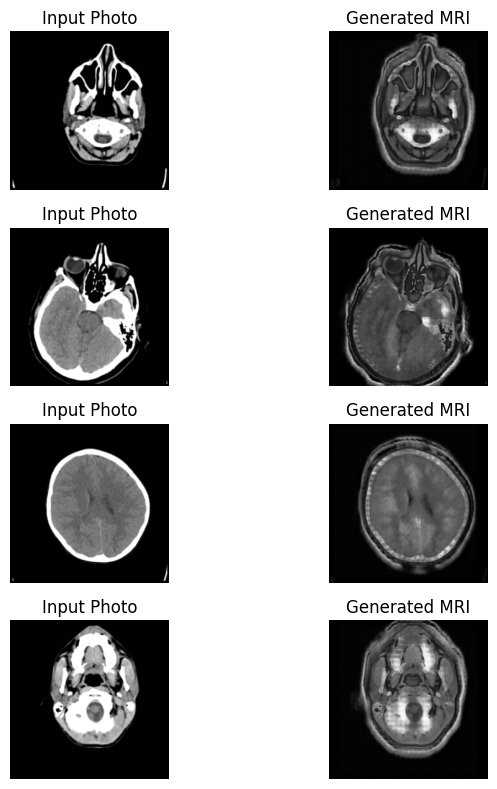

In [31]:
for test_batch in test_dataset.take(4):
    generated_MRI = cyclegan.generator_G(test_batch, training=False)
    show_image_batch(test_batch, generated_MRI)
    break 